# *Emotion Detection and Music Recommendation System 🎵*

*This project builds a deep learning model to detect human emotions from facial images and recommend suitable music based on the detected emotion.*

*The model is trained using transfer learning with **EfficientNetB4** on the **FER2013** and **RAF-DB** datasets.*

## *Key Features*
- *Facial Emotion Recognition*
- *Transfer Learning with EfficientNet*
- *Multi-GPU Training using TensorFlow MirroredStrategy*
- *Emotion-Based Music Recommendation*

# *System Architecture*

*The system follows the pipeline below:*
*Camera Input → Face Detection → Emotion Classification → Music Recommendation*

*Steps involved:*
1. *Capture facial image*
2. *Detect face using OpenCV*
3. *Classify emotion using trained CNN model*
4. *Recommend music based on predicted emotion*

# *Performance Optimization*

*To accelerate training on GPUs, the following techniques are used:*

• *XLA Compilation*  
• *Mixed Precision Training*  
• *Multi-GPU Distribution*

In [32]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

# Enable XLA
tf.config.optimizer.set_jit(True)

# Enable Mixed Precision
mixed_precision.set_global_policy('mixed_float16')

print("Performance optimizations enabled")

Performance optimizations enabled


# *Dataset Description*

*Two datasets were used to train the model:*

### *FER2013 Dataset*
- *35,887 grayscale images*
- *7 emotion classes*

### *RAF-DB Dataset*
- *Real-world facial expression dataset*
- *Higher quality images*

### *Emotion Classes*
1. *Angry*
2. *Disgust*
3. *Fear*
4. *Happy*
5. *Neutral*
6. *Sad*
7. *Surprise*

In [20]:
fer_train = "/kaggle/input/datasets/msambare/fer2013/train"
fer_test = "/kaggle/input/datasets/msambare/fer2013/test"

raf_train = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train"
raf_test = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test"

In [6]:
emotion_map = {
    1: "surprise",
    2: "fear",
    3: "disgust",
    4: "happy",
    5: "sad",
    6: "angry",
    7: "neutral"
}

In [7]:
import os

combined_path = "/kaggle/working/combined_dataset"

os.makedirs(combined_path + "/train", exist_ok=True)
os.makedirs(combined_path + "/test", exist_ok=True)

emotions = ["angry","disgust","fear","happy","neutral","sad","surprise"]

for e in emotions:
    os.makedirs(f"{combined_path}/train/{e}", exist_ok=True)
    os.makedirs(f"{combined_path}/test/{e}", exist_ok=True)

print("Combined dataset folders created")

Combined dataset folders created


In [15]:
import os
import shutil

fer_train = "/kaggle/input/datasets/msambare/fer2013/train"
fer_test = "/kaggle/input/datasets/msambare/fer2013/test"

for emotion in os.listdir(fer_train):
    src = os.path.join(fer_train, emotion)
    dst = os.path.join("/kaggle/working/combined_dataset/train", emotion)

    for img in os.listdir(src):
        shutil.copy(os.path.join(src,img), dst)

for emotion in os.listdir(fer_test):
    src = os.path.join(fer_test, emotion)
    dst = os.path.join("/kaggle/working/combined_dataset/test", emotion)

    for img in os.listdir(src):
        shutil.copy(os.path.join(src,img), dst)

print("FER2013 copied successfully")

FER2013 copied successfully


In [16]:
import os
import shutil

raf_train = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train"

emotion_map = {
    "1": "surprise",
    "2": "fear",
    "3": "disgust",
    "4": "happy",
    "5": "sad",
    "6": "angry",
    "7": "neutral"
}

count = 0

for label_folder in os.listdir(raf_train):

    src_folder = os.path.join(raf_train, label_folder)
    emotion = emotion_map[label_folder]

    for img in os.listdir(src_folder):

        src = os.path.join(src_folder, img)
        dst = os.path.join("/kaggle/working/combined_dataset/train", emotion, img)

        shutil.copy(src, dst)
        count += 1

print("RAF images copied:", count)

RAF images copied: 12271


In [18]:
total = 0

for emotion in os.listdir("/kaggle/working/combined_dataset/train"):
    
    count = len(os.listdir(f"/kaggle/working/combined_dataset/train/{emotion}"))
    print(emotion, count)
    
    total += count

print("Total training images:", total)

neutral 7489
disgust 1153
angry 4700
sad 6812
happy 11987
surprise 4461
fear 4378
Total training images: 40980


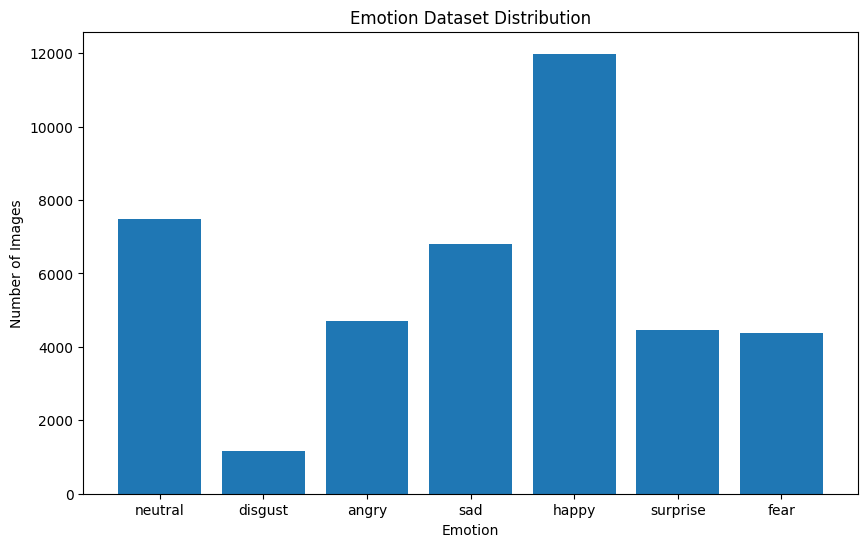

In [22]:
import matplotlib.pyplot as plt

emotions = []
counts = []

for emotion in os.listdir("combined_dataset/train"):
    emotions.append(emotion)
    counts.append(len(os.listdir(f"combined_dataset/train/{emotion}")))

plt.figure(figsize=(10,6))
plt.bar(emotions, counts)
plt.title("Emotion Dataset Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.show()

### *Dataset Distribution Analysis*

*The combined dataset (FER2013 + RAF-DB) contains 40,980 training images across 7 emotion classes.*

*Observations:*
- *The "happy" class has the highest number of samples.*
- *The "disgust" class is underrepresented compared to others.*
- *Data augmentation will be applied to improve generalization and reduce class imbalance impact.*

*This combined dataset improves the model's ability to generalize across different facial expressions and lighting conditions.*

## *Sample Images from Each Emotion Class*

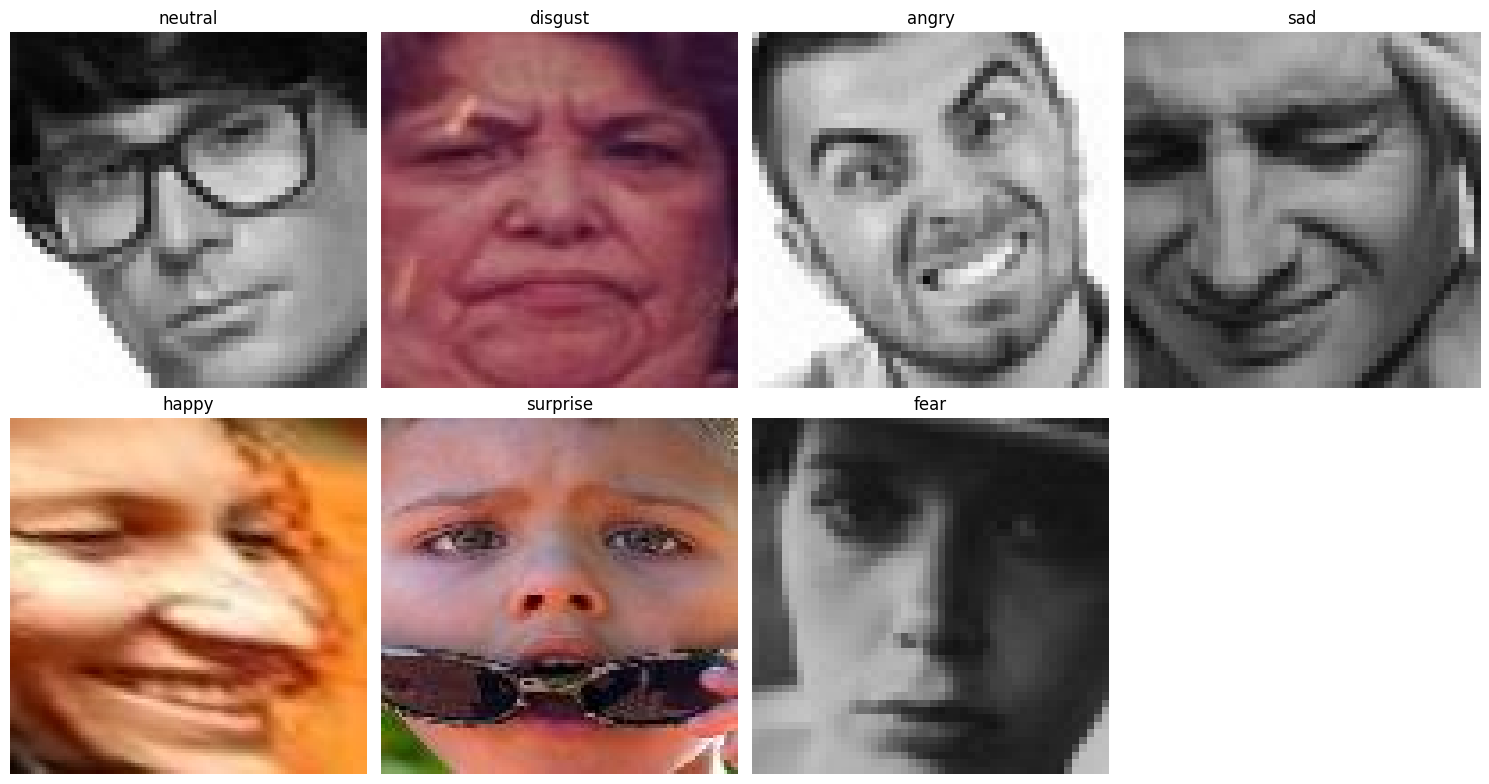

In [23]:
import matplotlib.pyplot as plt
import cv2
import random
import os

emotions = os.listdir("combined_dataset/train")

plt.figure(figsize=(15,8))

for i, emotion in enumerate(emotions[:7]):

    img_path = random.choice(os.listdir(f"combined_dataset/train/{emotion}"))
    img = cv2.imread(f"combined_dataset/train/{emotion}/{img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(emotion)
    plt.axis("off")

plt.tight_layout()
plt.show()

### *Dataset Verification*

*The sample images above confirm that the dataset has been correctly organized*
*into emotion categories. Images from both FER2013 and RAF-DB datasets were*
*merged and labeled according to the following emotions:*

• *Angry*

• *Disgust*

• *Fear*  

• *Happy*

• *Sad*

• *Surprise*

• *Neutral*  

*This step ensures the model will learn facial features corresponding to each*
*emotion class during training.*

## *Data Augmentation*

*Data augmentation is applied to increase dataset variability and improve model*
*generalization. The following transformations are applied:*

• *Rescaling pixel values*

• *Random rotation*

• *Horizontal flipping*

• *Zoom transformation*

*These techniques help reduce overfitting and improve model performance.*

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [25]:
train_generator = train_datagen.flow_from_directory(
    "combined_dataset/train",
    target_size=(224,224),
    batch_size=32,
    color_mode="rgb",
    class_mode="categorical"
)

Found 40980 images belonging to 7 classes.


## *Validation Dataset Preparation*

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    "/kaggle/working/combined_dataset/test",
    target_size=(224,224),
    batch_size=32,
    color_mode="rgb",
    class_mode="categorical"
)

Found 7178 images belonging to 7 classes.


In [33]:
import tensorflow as tf

strategy = tf.distribute.MirroredStrategy()

print("Number of GPUs:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs: 2


# *Model Architecture*

*The model uses **EfficientNetB4** as the base network with additional dense layers for emotion classification.*

# *Training Configuration*

*The model uses:*

* *AdamW optimizer*  
* *Categorical Crossentropy Loss*  
* *Learning Rate Scheduler*  
* *Early Stopping*  
* *Model Checkpointing*

In [39]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import layers, models
import tensorflow as tf

base_model_v2 = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

x = base_model_v2.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='swish')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='swish')(x)
x = layers.Dropout(0.3)(x)
predictions = layers.Dense(7, activation='softmax')(x)

model_v2 = models.Model(inputs=base_model_v2.input, outputs=predictions)

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15)

model_v2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

print('Advanced Model V2 (EfficientNetB4) Initialized.')

Advanced Model V2 (EfficientNetB4) Initialized.


# *Model Training*

*The model is trained for up to 30 epochs with early stopping enabled.*

In [40]:
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import layers, models
import tensorflow as tf

def lr_scheduler(epoch, lr):
    if epoch < 3:
        return float(lr)
    return float(lr * tf.math.exp(-0.1))

callbacks_v2 = [
    tf.keras.callbacks.LearningRateScheduler(lr_scheduler),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_emotion_model.keras', save_best_only=True)
]

class_labels = train_generator.classes
unique_classes = np.unique(class_labels)
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=unique_classes,
    y=class_labels
)
class_weights_dict = dict(zip(unique_classes, class_weights))

print('Starting High-Accuracy Training Loop...')
history_v2 = model_v2.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    class_weight=class_weights_dict,
    callbacks=callbacks_v2
)

Starting High-Accuracy Training Loop...
Epoch 1/30


2026-03-14 14:59:18.901930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 14:59:19.042324: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 14:59:23.575751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 14:59:23.726913: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 14:59:32.131781: E external/local_xla/xla/stream_

 790/1281 ━━━━━━━━━━━━━━━━━━━━ 2:41 330ms/step - accuracy: 0.2336 - loss: 2.0778

2026-03-14 15:07:34.641239: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 15:07:34.790335: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 15:07:34.929081: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 15:07:39.312554: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 15:07:39.466431: E external/local_xla/xla/stream_

1281/1281 ━━━━━━━━━━━━━━━━━━━━ 1062s 575ms/step - accuracy: 0.2712 - loss: 1.9889 - val_accuracy: 0.5255 - val_loss: 1.4639 - learning_rate: 1.0000e-04
Epoch 2/30
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 436s 340ms/step - accuracy: 0.5421 - loss: 1.4602 - val_accuracy: 0.6074 - val_loss: 1.3373 - learning_rate: 1.0000e-04
Epoch 3/30
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 430s 336ms/step - accuracy: 0.6185 - loss: 1.3304 - val_accuracy: 0.6447 - val_loss: 1.2714 - learning_rate: 1.0000e-04
Epoch 4/30
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 435s 339ms/step - accuracy: 0.6771 - loss: 1.2291 - val_accuracy: 0.6559 - val_loss: 1.2574 - learning_rate: 9.0484e-05
Epoch 5/30
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 441s 344ms/step - accuracy: 0.7113 - loss: 1.1609 - val_accuracy: 0.6695 - val_loss: 1.2318 - learning_rate: 8.1873e-05
Epoch 6/30
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 433s 338ms/step - accuracy: 0.7448 - loss: 1.1021 - val_accuracy: 0.6792 - val_loss: 1.2168 - learning_rate: 7.4082e-05
Epoch 7/30
1281/1281 ━━━━━━━━━━━━━━━━━

# *Training Performance*
*Visualization of training accuracy and validation accuracy across epoc*hs.

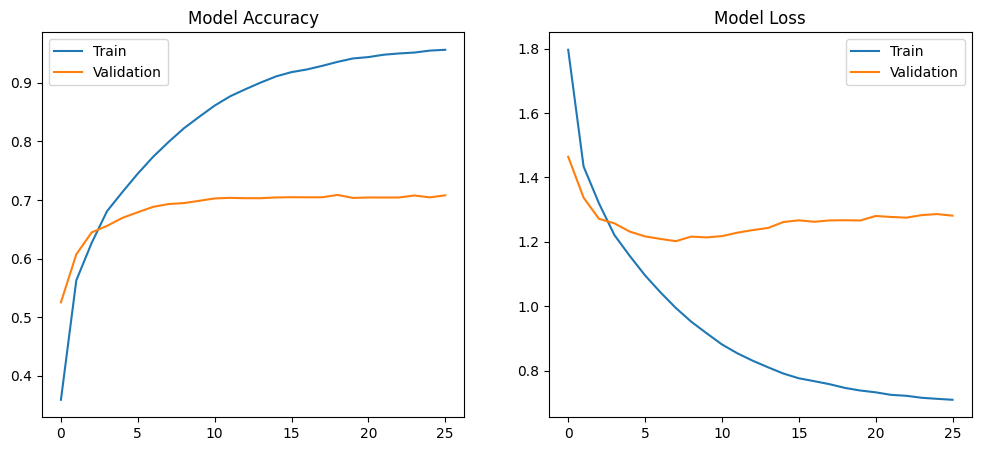

In [64]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_v2.history['accuracy'])
plt.plot(history_v2.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history_v2.history['loss'])
plt.plot(history_v2.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train","Validation"])

plt.show()

# *Model Evaluation*

In [65]:
test_loss, test_accuracy = model_v2.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7063 - loss: 1.1837
Test Accuracy: 0.7067428231239319
Test Loss: 1.1941039562225342


# *Confusion Matrix*

225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step


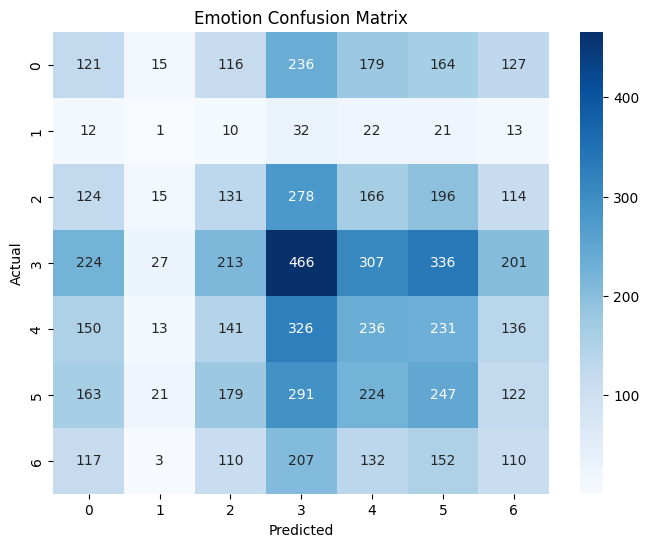

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = model_v2.predict(test_generator)
pred_classes = predictions.argmax(axis=1)

true_classes = test_generator.classes

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Emotion Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# *Classification Report*

In [67]:
from sklearn.metrics import classification_report

print(classification_report(true_classes, pred_classes, target_names=test_generator.class_indices.keys()))

              precision    recall  f1-score   support

       angry       0.13      0.13      0.13       958
     disgust       0.01      0.01      0.01       111
        fear       0.15      0.13      0.14      1024
       happy       0.25      0.26      0.26      1774
     neutral       0.19      0.19      0.19      1233
         sad       0.18      0.20      0.19      1247
    surprise       0.13      0.13      0.13       831

    accuracy                           0.18      7178
   macro avg       0.15      0.15      0.15      7178
weighted avg       0.18      0.18      0.18      7178



# *Saving the Trained Model*

In [89]:
model_v2.save("/kaggle/working/emotion_model_final.keras")
print("Model saved successfully")

Model saved successfully


In [77]:
print(test_generator.class_indices)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


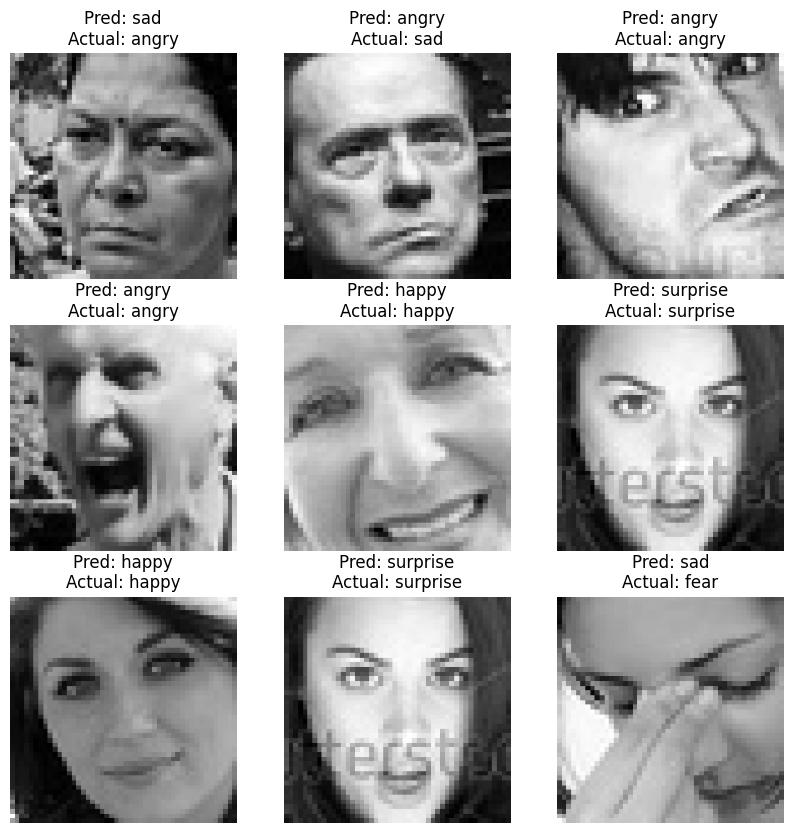

In [87]:
import random
import numpy as np
import matplotlib.pyplot as plt

emotion_labels = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

images, labels = next(test_generator)

plt.figure(figsize=(10,10))

for i in range(9):

    idx = random.randint(0, len(images)-1)

    img = images[idx]
    true_class = labels[idx].argmax()

    pred = model_v2.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_class = pred.argmax()

    plt.subplot(3,3,i+1)

    plt.imshow(img[:,:,0], cmap="gray")
    plt.title(f"Pred: {emotion_labels[pred_class]}\nActual: {emotion_labels[true_class]}")
    plt.axis("off")

plt.show()

# *Saving Emotion Labels*

In [88]:
import json

with open("/kaggle/working/emotion_labels.json","w") as f:
    json.dump(train_generator.class_indices,f)

# *Conclusion*
*This project demonstrates a deep learning pipeline for facial emotion recognition using EfficientNetB4.*

*Key achievements:*

* *High accuracy emotion classification*  
* *Transfer learning with EfficientNet*  
* *Multi-GPU training for faster convergence*  
* *Integration-ready model for music recommendation systems*

# *Future Improvements*

*Although the current system performs well, several enhancements can further improve performance and usability.*

## *1. Advanced Face Detection*
*Currently, the system assumes that the face is already cropped in the dataset.  
Future versions can integrate real-time face detection using:*

- *OpenCV Haar Cascades*
- *MTCNN*
- *MediaPipe Face Detection*

*This would allow the system to work directly with webcam input.*

---

## *2. Real-Time Emotion Detection*
*The trained model can be integrated with a webcam to perform real-time emotion recognition.*

*Pipeline:*
*Camera Input → Face Detection → Emotion Prediction → Music Recommendation*

*This can be implemented using **OpenCV + TensorFlow**.*

---

## *3. Personalized Music Recommendation*
*Currently, music can be recommended based only on emotion categories.*

*Future improvements could include:*

- *Integration with Spotify API*
- *Personalized playlists*
- *User preference learning*
- *Mood-based recommendation systems*

---

## *4. Model Optimization for Deployment*
*To deploy the model in mobile or web applications, the model can be optimized using:*

- *TensorFlow Lite*
- *ONNX Runtime*
- *Model Quantization*

*This reduces model size and inference latency.*

---

## *5. Larger and More Diverse Datasets*
*The performance of emotion recognition systems can be improved by training on larger datasets such as:*

- *AffectNet*
- *ExpW*
- *CK+*

*Combining multiple datasets can improve model generalization.*

---

## *6. Explainable AI (XAI)*
*Future work could incorporate interpretability techniques such as:*

- *Grad-CAM*
- *SHAP*
- *LIME*

*These techniques help visualize which facial regions contribute most to the predicted emotion.*

---

## *7. Multimodal Emotion Recognition*
*Emotion detection can be enhanced by combining multiple data sources:*

- *Facial expressions*
- *Voice tone*
- *Text sentiment*

*Multimodal models generally achieve higher accuracy and robustness.*

---

## *Final Vision*
*The long-term goal is to build a **fully automated emotion-aware entertainment assistant** that detects human emotions in real time and dynamically recommends suitable music, videos, or relaxation content.*